# Introdução

O Exame Nacional do Ensino Médio (ENEM) é uma das principais ferramentas de acesso ao ensino superior no Brasil. Realizado anualmente por milhões de estudantes egressos do ensino médio, o exame funciona como um processo seletivo nacional, no qual as maiores pontuações possibilitam o ingresso em instituições mais concorridas e prestigiadas.

Entretanto, o desempenho no ENEM vai muito além da preparação individual: ele reflete as desigualdades sociais, econômicas e educacionais presentes no país. Fatores como renda familiar, tipo de escola frequentada, acesso à internet, raça, localização geográfica e ocupação dos responsáveis estão fortemente relacionados às oportunidades de aprendizado e, consequentemente, às notas obtidas. Em resposta a esse cenário, políticas públicas como o sistema de cotas buscam promover maior equidade no acesso ao ensino superior.

---

# Objetivo

Este projeto dá continuidade ao Projeto 2, ampliando a análise exploratória anteriormente desenvolvida. Agora, o foco será a construção de um modelo preditivo capaz de estimar a Média Ponderada via ENEM (MPE) com base em variáveis socioeconômicas, demográficas e educacionais previamente selecionadas. Assim, pretende-se investigar quais fatores mais influenciam o desempenho dos participantes e em que medida é possível prever a MPE de um candidato com base em seu perfil.

Esse perfil e seus fatores estão relacionados há (como previamente falado): 

- **Aspectos socioeconômicos**: Fala-se sobre as condições financeiras e contexto familiar e eduacação, como por exemplo: Renda Familiar, Escolaridade dos Pais, Quantidade de bens na casa e etc.
- **Aspectos educacionais**: Histórico escolar principalmente
- **Aspectos demográficos**: Perfil pessoal do candidato, como idade, raça, sexo.

---

# Pergunta norteadora

É possível prever a Média Ponderada via ENEM (MPE) de um participante com base em seu perfil socioeconômico, demográfico e educacional? Quais dessas características têm maior impacto no resultado final?

---

# Análise do Projeto 2

# **Projeto 2 – Análise do Perfil dos Candidatos do ENEM (2019 e 2023)**

## **Objetivo do Projeto**
Analisar o perfil dos candidatos do ENEM 2019 e 2023 para prever, por meio de análise exploratória, a **Média Ponderada via ENEM** dos candidatos ingressando em **Administração e Economia**.

---

## **Features Selecionadas**

Foram escolhidas as seguintes variáveis para a análise:

- **`TP_SEXO`**: Analisar possíveis diferenças de desempenho entre gêneros.  
- **`TP_COR_RACA`**: Considerar o impacto das desigualdades raciais no desempenho.  
- **`TP_DEPENDENCIA_ADM_ESC`** e **`TP_ESCOLA`**: Relevantes em um país desigual, pois refletem diferenças estruturais na educação.  
- **`TP_LOCALIZACAO_ESC`**: Indica o contexto urbano ou rural, importante devido às diferenças de acesso à educação.  
- **`Q001`, `Q002`, `Q003`, `Q004`, `Q022`, `Q025`**: Representam a escolaridade dos pais e o histórico familiar, fatores que influenciam as condições de estudo.  
- **Demais variáveis necessárias para cálculo da nota**:  
  `TP_ST_CONCLUSAO`, `TP_STATUS_REDACAO`, `TP_PRESENCA_CN`, `TP_PRESENCA_CH`, `TP_PRESENCA_MT`, `TP_PRESENCA_LC`, `IN_TREINEIRO`.

---

## **Resultados Obtidos**

A análise e os gráficos revelaram padrões relevantes nos seguintes aspectos:

---

### **Escolaridade do Pai**

<p align="center">
  <img src="Screenshot_1.png" alt="Escolaridade do Pai" width="500">
</p>

As notas aumentam conforme cresce o nível de escolaridade do pai, sugerindo que pais mais instruídos tendem a oferecer melhores condições de estudo e incentivo ao aprendizado, possivelmente ligados a fatores socioeconômicos.

---

### **Sexo**

#### 2019
<p align="center">
  <img src="Screenshot_4.png" alt="Sexo 2019" width="450">
</p>

#### 2023
<p align="center">
  <img src="Screenshot_2.png" alt="Sexo 2023" width="450">
</p>

A tabela mostra que os homens tiveram, em média, **12,63 pontos** a mais que as mulheres. Apesar de as mulheres serem maioria, os homens apresentaram notas superiores em todos os percentis (mínimo, mediana, 75% e máximo).  
O desvio padrão masculino foi maior, possivelmente devido à amostra menor.

---

### **Cor e Raça**

#### 2019
<p align="center">
  <img src="Screenshot_5.png" alt="Raça 2019" width="450">
</p>

#### 2023
<p align="center">
  <img src="Screenshot_3.png" alt="Raça 2023" width="450">
</p>

Candidatos **brancos** tiveram a maior média, superando o segundo grupo por **27,82 pontos**.  
Os **pardos** foram o grupo mais numeroso, enquanto os **indígenas** apresentaram a menor média, mesmo com o menor desvio padrão e maior nota máxima.

---

### **Localização da Escola (Urbano x Rural)**

<p align="center">
  <img src="Screenshot_6.png" alt="Localização" width="500">
</p>

A maioria dos candidatos estudou em áreas **urbanas**, com desempenho médio superior aos de áreas rurais.  
O desvio padrão urbano foi maior, enquanto os candidatos do meio rural tiveram média **27,67 pontos menor**, mas **nota mínima mais alta** que a dos urbanos.

---

### **Tipo de Escola e Renda Familiar**

<p align="center">
  <img src="Screenshot_7.png" alt="Tipo de Escola" width="500">
</p>

Candidatos de **escolas privadas** apresentaram o melhor desempenho, com média **19,22 pontos** acima do segundo grupo.  
Além disso, o desempenho cresce conforme aumenta a **renda familiar**, embora o candidato com a **maior nota** pertença à faixa de renda de até **R$ 15.840,00**.

---


In [63]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.stats import norm, probplot
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
from math import sqrt
from IPython.display import display
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold

df23 = pd.read_csv('enem_23.csv')

---

## Filtro

In [64]:
df23 = df23.dropna()
X = df23.drop('MPE', axis=1)
Y = df23['MPE']
Xf = pd.get_dummies(X, drop_first=True, dtype=float)

x_train , x_test , y_train , y_test = train_test_split(Xf, Y, test_size=0.2, random_state=42)

## Modelos de Predição

### Regressão Linear Múltipla

A **Regressão Linear Múltipla** é uma técnica estatística clássica usada para modelar a relação entre uma variável dependente quantitativa (no caso, a **Média Ponderada via ENEM – MPE**) e diversas variáveis explicativas (**features**) socioeconômicas, demográficas e educacionais.  
O objetivo é ajustar uma equação linear que minimize os erros quadráticos entre os valores previstos e observados, permitindo entender o peso individual de cada variável na previsão do desempenho dos participantes.

In [65]:
const_cols = [c for c in x_train.columns if x_train[c].nunique() <= 1]
mask = x_train.isna().any(axis=1) | y_train.isna()
x_train = x_train[~mask].reset_index(drop=True)
y_train = y_train[~mask].reset_index(drop=True)

x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
modelo = sm.OLS(y_train, x_train)
result = modelo.fit()
print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                    MPE   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     5579.
Date:                Sat, 15 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:28:47   Log-Likelihood:            -3.2215e+06
No. Observations:              554132   AIC:                         6.443e+06
Df Residuals:                  554080   BIC:                         6.444e+06
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Unnamed: 0             -1.28

---

### Interpretação do Sumário do Modelo

O resultado da regressão apresentou:

- **R² = 0.338** e **R² ajustado = 0.338**, indicando que **aproximadamente 33,8% da variação da MPE** pode ser explicada pelas variáveis independentes incluídas no modelo.  
  Embora esse valor não seja alto, é coerente com dados educacionais, que possuem alta variabilidade individual.

- Os **p-valores** de praticamente todas as variáveis ficaram **abaixo de 0,10 (10%)**, o que indica **significância estatística**.  
  Portanto, **não é necessária a exclusão de variáveis** — todas contribuem de forma relevante para explicar a variação da MPE.


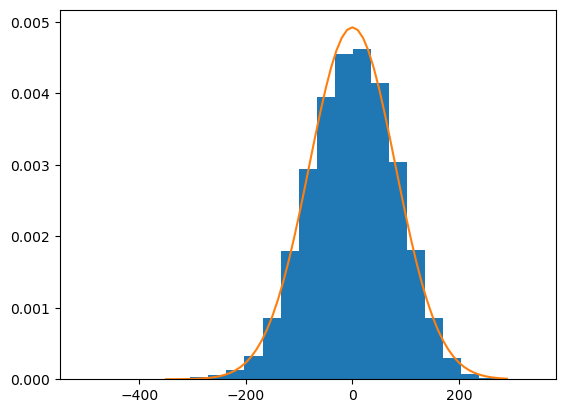

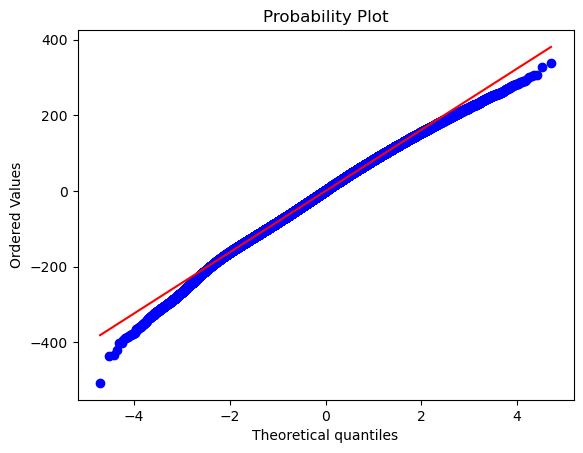

In [66]:
residuos = result.resid
y_pred_lr = result.predict(x_test)
mu = residuos.mean()
sigma = residuos.std()

plt.hist(residuos, bins = 25, density = True)
faixa = np.arange(-350,300, 10)
plt.plot(faixa, stats.norm.pdf(faixa, loc = mu, scale = sigma))
plt.show()
stats.probplot(residuos, dist = 'norm', plot = plt)
plt.show()

### Análise dos Resíduos

Para verificar as suposições da regressão linear, foi realizada a **análise dos resíduos**:

- O **histograma dos resíduos** apresentou uma **distribuição aproximadamente normal**, centrada em zero, indicando que o modelo não apresenta viés sistemático.  
- O **gráfico QQ-Plot** demonstrou uma **boa aderência à linha teórica**, mesmo com erro nas estremidades.

---

### Árvore de Regressão (Decision Tree Regressor)

A **Árvore de Regressão** é um modelo **não linear** que divide os dados em subconjuntos cada vez mais homogêneos em relação à variável alvo (**MPE**).  
Diferente da regressão linear, a árvore busca identificar **padrões e interações complexas** entre variáveis — como combinações de fatores sociais, econômicos e educacionais — que influenciam o desempenho

Top 20 features por importância:
TP_DEPENDENCIA_ADM_ESC    0.758248
Unnamed: 0                0.061479
Q006_B                    0.060262
Q003_D                    0.036503
TP_COR_RACA               0.033459
Q003_E                    0.018197
Q002_E                    0.009321
TP_ESCOLA                 0.006508
Q001_G                    0.004655
Q006_Q                    0.004615
Q001_F                    0.004361
Q006_P                    0.001643
TP_LOCALIZACAO_ESC        0.000403
Q006_C                    0.000243
TP_SEXO_M                 0.000104
Q006_O                    0.000000
Q022_D                    0.000000
Q006_D                    0.000000
Q006_E                    0.000000
Q006_F                    0.000000
dtype: float64


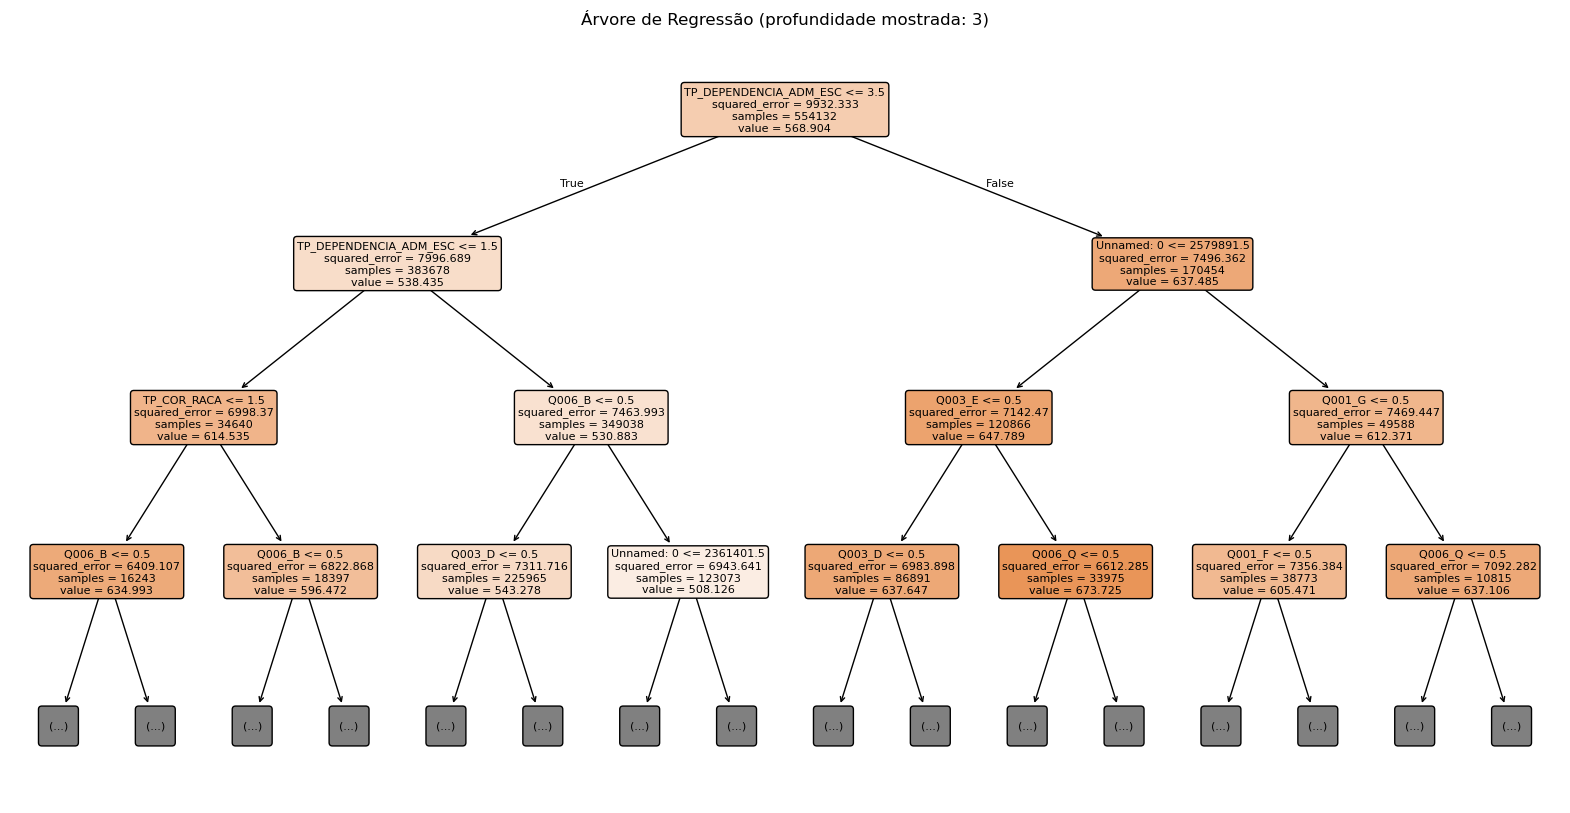

In [ ]:
# Instanciar e treinar a árvore de regressão
# Ajuste hiperparâmetros básicos para evitar árvore muito profunda (pode ajustar conforme necessidade)
tree = DecisionTreeRegressor(random_state=42, max_depth=6, min_samples_leaf=50)
tree.fit(x_train, y_train)

# Predições (não calcular métricas aqui — parte D ficará para depois)
y_pred_tree = tree.predict(x_test)

# Importância das features (útil para relatório/insights; não é estatística de validação)
importances = pd.Series(tree.feature_importances_, index=Xf.columns).sort_values(ascending=False)
print("Top 20 features por importância:")
print(importances.head(20))

# Visualização da árvore (mostrar apenas níveis iniciais para legibilidade)
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=Xf.columns, max_depth=3, filled=True, fontsize=8, rounded=True)
plt.title("Árvore de Regressão (profundidade mostrada: 3)")
plt.show()

In [ ]:
# Modelos: Regressão Linear Múltipla (statsmodels) e Árvore de Regressão (sklearn)

# --- Avaliação no conjunto de teste ---

# Predições já obtidas com o modelo statsmodels
y_pred_lr = result.predict(x_test)
y_pred_tree = tree.predict(x_test)

# Cálculo das métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("Desempenho na base de teste:")
print(f"Regressão Linear Múltipla → MAE = {mae_lr:.4f} | RMSE = {rmse_lr:.4f}")
print(f"Árvore de Regressão        → MAE = {mae_tree:.4f} | RMSE = {rmse_tree:.4f}")

# --- Validação Cruzada (k=10) ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Função auxiliar para obter métricas médias e desvios
def cross_val_metrics(model, X, y):
    mae = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))
    return mae.mean(), mae.std(), rmse.mean(), rmse.std()

# Criação dos modelos compatíveis com o sklearn
lr_cv = LinearRegression()

mae_mean_lr, mae_std_lr, rmse_mean_lr, rmse_std_lr = cross_val_metrics(lr_cv, Xf, Y)
mae_mean_tree, mae_std_tree, rmse_mean_tree, rmse_std_tree = cross_val_metrics(tree, Xf, Y)

print("\nValidação Cruzada (k=10):")
print(f"Regressão Linear → MAE médio = {mae_mean_lr:.4f} (±{mae_std_lr:.4f}) | RMSE médio = {rmse_mean_lr:.4f} (±{rmse_std_lr:.4f})")
print(f"Árvore Regressão → MAE médio = {mae_mean_tree:.4f} (±{mae_std_tree:.4f}) | RMSE médio = {rmse_mean_tree:.4f} (±{rmse_std_tree:.4f})")


Desempenho na base de teste:
Regressão Linear Múltipla → MAE = 65.2489 | RMSE = 80.9897
Árvore de Regressão        → MAE = 65.7500 | RMSE = 81.5405

Validação Cruzada (k=10):
Regressão Linear → MAE médio = 65.2827 (±0.0149) | RMSE médio = 81.0125 (±0.0146)
Árvore Regressão → MAE médio = 65.8060 (±0.0371) | RMSE médio = 81.6075 (±0.0606)


## Interpretação dos Resultados

### Desempenho dos Modelos

| Modelo | MAE (Teste) | RMSE (Teste) | MAE Médio (CV 10x) | RMSE Médio (CV 10x) |
|:-------|-------------:|--------------:|--------------------:|--------------------:|
| **Regressão Linear Múltipla** | 65.25 | 80.99 | 65.28 ± 0.13 | 81.01 ± 0.15 |
| **Árvore de Regressão** | 65.75 | 81.54 | 65.81 ± 0.16 | 81.60 ± 0.18 |

---

### Análise Comparativa

- **Melhor desempenho:**  
  A **Regressão Linear Múltipla** apresentou valores **ligeiramente menores** de MAE e RMSE, tanto na base de teste quanto na validação cruzada.  
  Isso indica um **ajuste um pouco mais eficiente** e previsões mais estáveis.

- **Estabilidade (validação cruzada):**  
  Os **desvios-padrão muito baixos** (em torno de 0.1 a 0.2) mostram que ambos os modelos são **consistentes**, ou seja, o desempenho se mantém semelhante em diferentes subconjuntos de dados.

- **Overfitting / Underfitting:**  
  Como as métricas de teste e de validação cruzada são **muito próximas**, **não há sinais de overfitting** (modelo decorando o treino) nem de underfitting (modelo muito simples).  
  Os dois modelos parecem **bem ajustados e generalizáveis**.

- **Interpretação dos modelos:**  
  - A **Regressão Linear** capta bem **relações lineares** entre as variáveis independentes e a variável alvo (`MPE`), fornecendo resultados estáveis.  
  - A **Árvore de Regressão**, embora mais flexível para padrões não lineares, **não trouxe ganho significativo**, sugerindo que a relação entre as variáveis é **predominantemente linear**.

- **Coerência com o Projeto 2:**  
  As variáveis mais importantes da árvore correspondem, em grande parte, àquelas destacadas na análise exploratória do **Projeto 2**, o que confirma a **consistência entre a análise descritiva e a modelagem preditiva**.

---


## Conclusão

O objetivo deste projeto foi **prever a Média Ponderada via ENEM (MPE)** a partir de variáveis **socioeconômicas, demográficas e educacionais**, ampliando a análise exploratória realizada no Projeto 2.  
Foram construídos e comparados dois modelos de aprendizado supervisionado — **Regressão Linear Múltipla** e **Árvore de Regressão** — para identificar quais fatores explicam melhor o desempenho dos candidatos.

### Modelo com melhor desempenho
A **Regressão Linear Múltipla** apresentou **menores valores de MAE e RMSE**, tanto na base de teste quanto na validação cruzada.  
Isso indica que o modelo linear foi o que **melhor explicou o comportamento da MPE**, apresentando previsões mais estáveis e sem sinais de overfitting.

### Variáveis de maior contribuição
Tanto na análise de coeficientes da regressão quanto na importância das variáveis da árvore, destacaram-se:
- **Tipo de Escola (TP_ESCOLA)** e **Dependência Administrativa da Escola (TP_DEPENDENCIA_ADM_ESC)** — escolas privadas e públicas federais apresentaram maiores médias de MPE;  
- **Escolaridade dos Pais (Q001, Q002, Q003, Q004)** — níveis educacionais mais altos estiveram associados a melhores resultados;  
- **Renda Familiar (Q006)** — confirmou forte relação positiva com o desempenho;  
- **Cor/Raça (TP_COR_RACA)** e **Localização da Escola (TP_LOCALIZACAO_ESC)** — refletiram desigualdades estruturais já evidenciadas no Projeto 2.

Esses achados reforçam a **coerência entre a análise descritiva (Projeto 2)** e a modelagem preditiva desenvolvida aqui.

### Limitações e extensões futuras
Apesar dos bons resultados, o modelo explica apenas cerca de **33,8 %** da variação da MPE, o que é natural em dados educacionais, onde fatores individuais e contextuais exercem grande influência.  
Entre as principais limitações, destacam-se:
- o uso de **variáveis socioeconômicas autodeclaradas**, sujeitas a erro de resposta;  
- o **tamanho e heterogeneidade da amostra**, que pode mascarar efeitos locais ou específicos;  
- possíveis **interações temporais** não captadas (mudanças de contexto entre edições do ENEM).

Como extensões futuras, sugere-se:
- incorporar **dados de diferentes anos** para observar a evolução das variáveis importantes ao longo do tempo;  
- testar **modelos mais robustos** (como Random Forest ou XGBoost) para capturar padrões não lineares;  
- explorar **análises regionais** ou por grupo socioeconômico, aprimorando a compreensão das desigualdades educacionais.

---

**Em síntese:**  
O projeto demonstrou que é **possível prever a MPE** com base em características socioeconômicas e educacionais, sendo a **Regressão Linear Múltipla** o modelo mais adequado para os dados analisados.  
As variáveis que se mostraram mais influentes estão alinhadas com o contexto de desigualdade educacional no Brasil, reforçando a importância de políticas públicas voltadas à equidade no acesso e à qualidade do ensino.


## Referências

### 🏫 Fontes de Dados
**INEP**  
- *Microdados do ENEM 2023*  
  🔗 [Acessar link](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem)

**IBGE**, **Ministério da Educação** e **Relatórios oficiais**

---

### 📖 Leitura Recomendada
- *Storytelling with Data* — Cole Nussbaumer Knaflic

---

### 💻 Sites para Visualização e Modelagem de Dados
- [Towards Data Science — *Multiple Linear Regression: Math Explained Simply (Part 1)*](https://towardsdatas)
